In [2]:
import pandas as pd

In [3]:
import pandas as pd
df = pd.read_csv('/content/movies.csv')
display(df.head())

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [5]:
genre_analysis = df.groupby('genre').agg(
    avg_gross=('gross', 'mean'),
    avg_score=('score', 'mean'),
    num_movies=('name', 'count'),
    avg_budget=('budget', 'mean') # Added average budget calculation
).reset_index()

# Sort by average gross revenue (consumption)
print("Top 10 Genres by Average Gross Revenue (Consumption):")
display(genre_analysis.sort_values(by='avg_gross', ascending=False).head(10))

# Sort by average score
print("\nTop 10 Genres by Average Score:")
display(genre_analysis.sort_values(by='avg_score', ascending=False).head(10))

Top 10 Genres by Average Gross Revenue (Consumption):


,genre,avg_gross,avg_score,num_movies,avg_budget
2,Animation,2.392300e+08,6.769231,338,7.578520e+07
7,Family,1.961725e+08,6.363636,11,5.112500e+07
0,Action,1.455086e+08,6.202817,1705,5.808460e+07
1,Adventure,1.093252e+08,6.291569,427,4.570839e+07
13,Mystery,1.011835e+08,6.665000,20,3.187647e+07
3,Biography,4.787432e+07,7.030926,443,2.531232e+07
10,Horror,4.737241e+07,5.750621,322,1.282516e+07
4,Comedy,4.433187e+07,6.193987,2245,2.260780e+07
5,Crime,3.940120e+07,6.671506,551,2.236357e+07
6,Drama,3.893096e+07,6.693668,1518,2.291461e+07



Top 10 Genres by Average Score:


,genre,avg_gross,avg_score,num_movies,avg_budget
9,History,NaN,8.300000,1,3.235620e+05
12,Musical,2.595346e+06,8.050000,2,NaN
11,Music,1.100140e+05,7.200000,1,NaN
3,Biography,4.787432e+07,7.030926,443,2.531232e+07
2,Animation,2.392300e+08,6.769231,338,7.578520e+07
6,Drama,3.893096e+07,6.693668,1518,2.291461e+07
5,Crime,3.940120e+07,6.671506,551,2.236357e+07
13,Mystery,1.011835e+08,6.665000,20,3.187647e+07
14,Romance,2.354937e+07,6.410000,10,2.404000e+07
7,Family,1.961725e+08,6.363636,11,5.112500e+07


Este código realiza os seguintes passos:

1.  **Agrupamento por Gênero**: Ele agrupa o DataFrame `df` pela coluna `genre`.
2.  **Agregação**: Para cada gênero, ele calcula a média da 'gross' (receita bruta, representando o consumo) e a média do 'score' (pontuação). Também conta o número de filmes por gênero para ter um contexto.
3.  **Ordenação por Receita**: Em seguida, ele classifica os gêneros em ordem decrescente pela receita bruta média e exibe os 10 principais, mostrando quais gêneros geram mais receita.
4.  **Ordenação por Pontuação**: Depois, ele classifica os gêneros em ordem decrescente pela pontuação média e exibe os 10 principais, mostrando quais gêneros são mais bem avaliados.

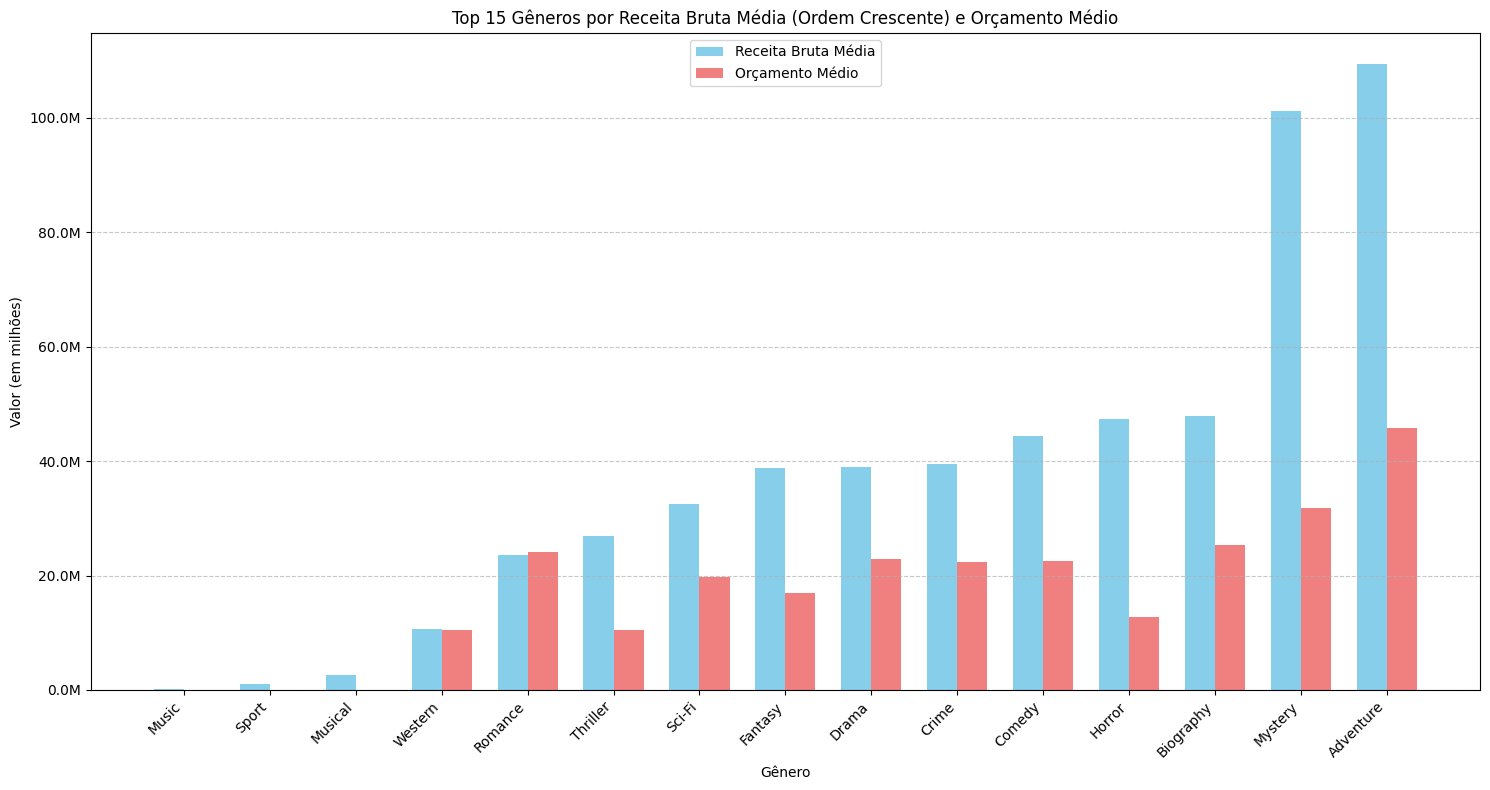

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Get top 15 genres by average gross revenue, sorted in ASCENDING order
top_15_genres_gross = genre_analysis.sort_values(by='avg_gross', ascending=True).head(15)

# Set the positions for the bars on the x-axis
x = np.arange(len(top_15_genres_gross['genre']))

# Set the width of the bars
width = 0.35

fig, ax = plt.subplots(figsize=(15, 8))

# Plotting Average Gross Revenue
rects1 = ax.bar(x - width/2, top_15_genres_gross['avg_gross'], width, label='Receita Bruta Média', color='skyblue')

# Plotting Average Budget
rects2 = ax.bar(x + width/2, top_15_genres_gross['avg_budget'], width, label='Orçamento Médio', color='lightcoral')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Gênero')
ax.set_ylabel('Valor (em milhões)')
ax.set_title('Top 15 Gêneros por Receita Bruta Média (Ordem Crescente) e Orçamento Médio') # Updated title
ax.set_xticks(x)
ax.set_xticklabels(top_15_genres_gross['genre'], rotation=45, ha="right")
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Format y-axis to be more readable (e.g., in millions)
formatter = plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M')
ax.yaxis.set_major_formatter(formatter)

fig.tight_layout()
plt.show()

Este gráfico de barras mostra os 15 gêneros com a maior receita bruta média. Para cada gênero, são apresentadas duas barras:

*   **Receita Bruta Média (azul claro)**: Indica o consumo médio, ou seja, quanto dinheiro o gênero gerou em média.
*   **Orçamento Médio (vermelho claro)**: Indica o investimento médio necessário para produzir filmes daquele gênero.

Com este gráfico, é possível comparar diretamente o retorno financeiro (consumo) e o custo de produção (orçamento) entre os gêneros mais populares.

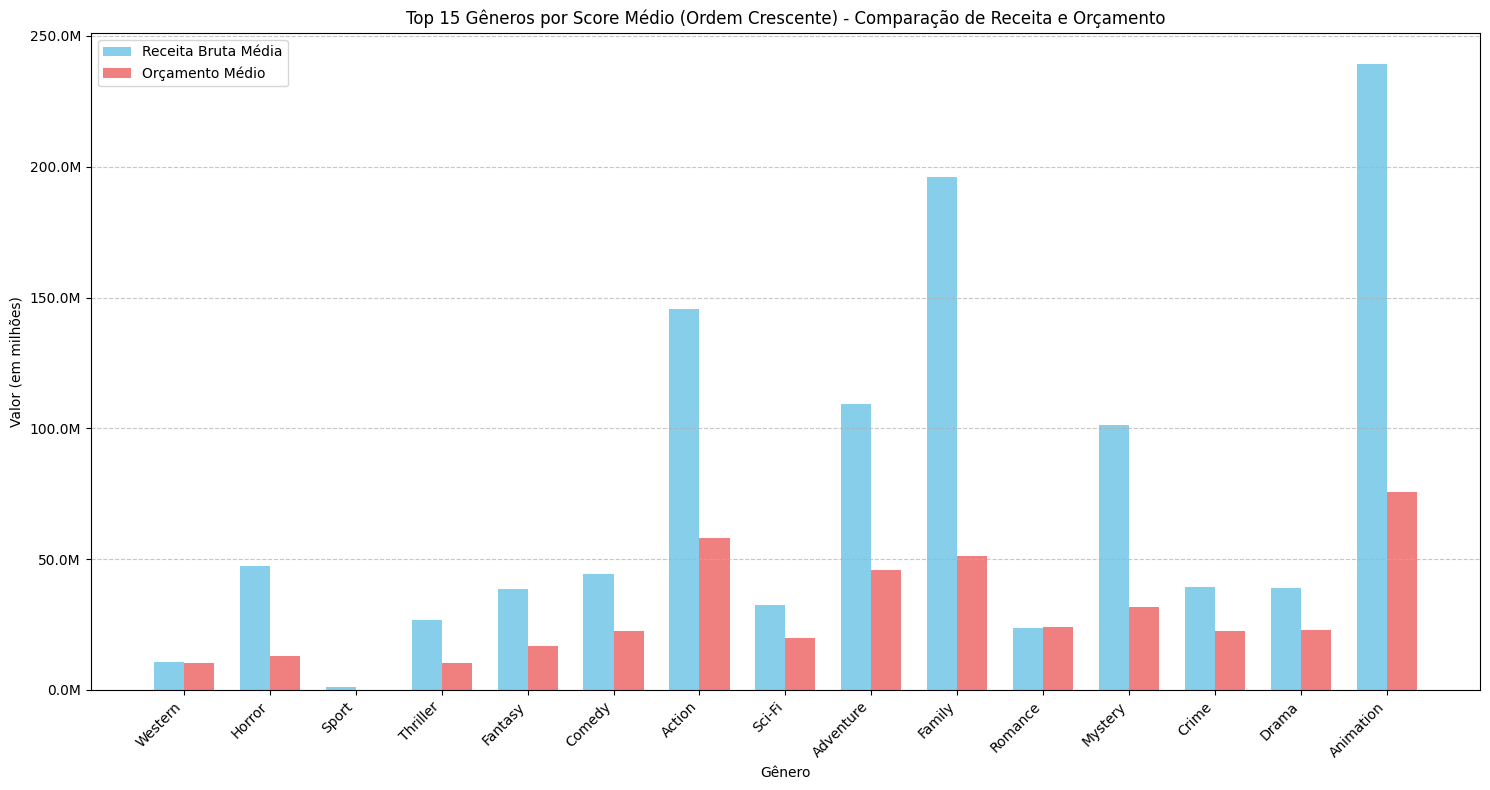

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Get top 15 genres by average score, sorted in ASCENDING order
top_15_genres_score = genre_analysis.sort_values(by='avg_score', ascending=True).head(15)

# Set the positions for the bars on the x-axis
x = np.arange(len(top_15_genres_score['genre']))

# Set the width of the bars
width = 0.35

fig, ax = plt.subplots(figsize=(15, 8))

# Plotting Average Gross Revenue
rects1 = ax.bar(x - width/2, top_15_genres_score['avg_gross'], width, label='Receita Bruta Média', color='skyblue')

# Plotting Average Budget
rects2 = ax.bar(x + width/2, top_15_genres_score['avg_budget'], width, label='Orçamento Médio', color='lightcoral')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Gênero')
ax.set_ylabel('Valor (em milhões)')
ax.set_title('Top 15 Gêneros por Score Médio (Ordem Crescente) - Comparação de Receita e Orçamento') # Updated title
ax.set_xticks(x)
ax.set_xticklabels(top_15_genres_score['genre'], rotation=45, ha="right")
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Format y-axis to be more readable (e.g., in millions)
formatter = plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M')
ax.yaxis.set_major_formatter(formatter)

fig.tight_layout()
plt.show()

Este gráfico de barras mostra os 15 gêneros com os maiores scores médios, ordenados de forma crescente pela pontuação. Para cada gênero, são apresentadas duas barras:

*   **Receita Bruta Média (azul claro)**: Indica o consumo médio e o retorno financeiro.
*   **Orçamento Médio (vermelho claro)**: Indica o investimento médio necessário.

Com este gráfico, você pode analisar se os gêneros com pontuações mais altas necessariamente se correlacionam com maior receita ou orçamento, e vice-versa.

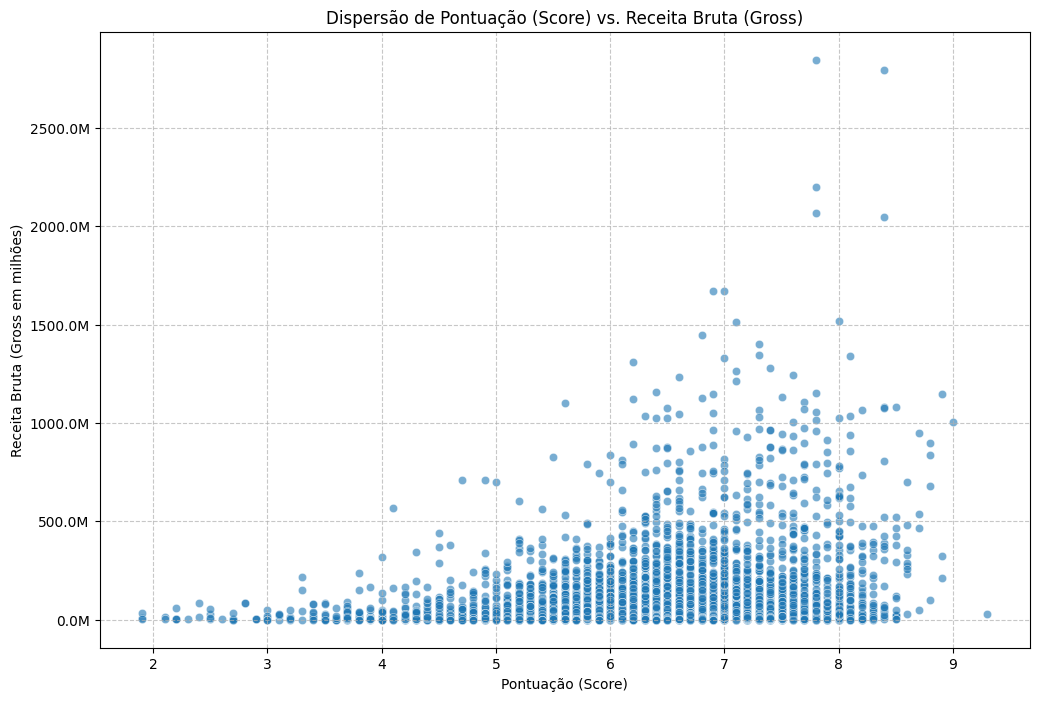

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='score', y='gross', alpha=0.6)
plt.title('Dispersão de Pontuação (Score) vs. Receita Bruta (Gross)')
plt.xlabel('Pontuação (Score)')
plt.ylabel('Receita Bruta (Gross em milhões)')

# Format y-axis to be more readable (e.g., in millions)
formatter = plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Este gráfico de dispersão visualiza a relação entre a pontuação (score) de um filme e sua receita bruta (gross). Cada ponto no gráfico representa um filme.

*   O **eixo X** mostra a pontuação do filme.
*   O **eixo Y** mostra a receita bruta do filme.

Observando a distribuição dos pontos, podemos inferir se existe uma correlação entre as pontuações dos filmes e o sucesso financeiro (receita bruta). Por exemplo, podemos procurar por padrões como filmes com pontuações mais altas que geralmente têm receitas brutas maiores, ou se há muitos filmes com pontuações médias que ainda assim geram muita receita.

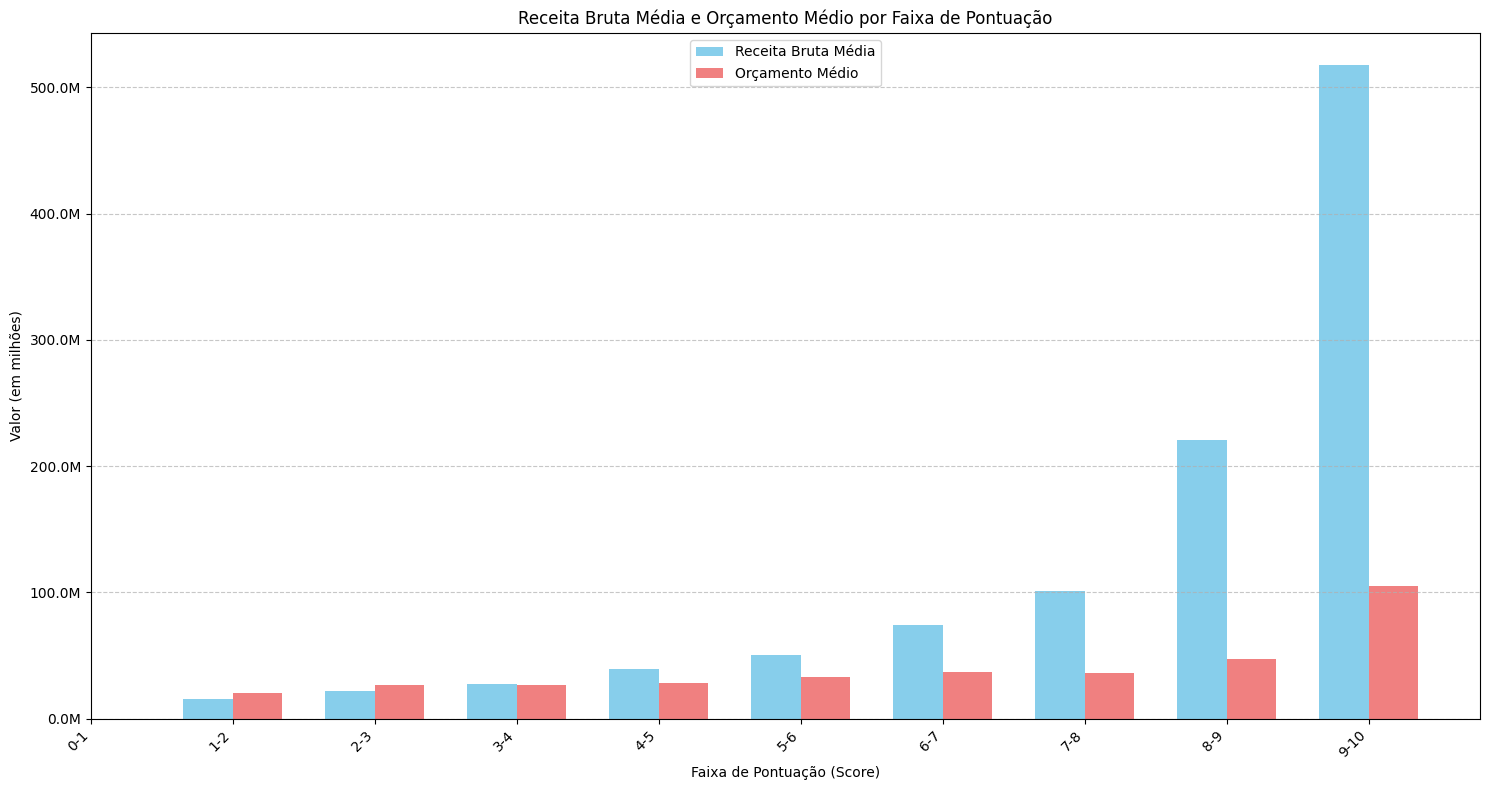

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Define score bins (e.g., 0-1, 1-2, ..., 9-10)
score_bins = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
score_labels = [f'{i}-{i+1}' for i in range(10)]

# Create a new column for score bins
df['score_bin'] = pd.cut(df['score'], bins=score_bins, labels=score_labels, right=False)

# Group by score bin and calculate the average gross and average budget
score_analysis = df.groupby('score_bin', observed=False).agg(
    avg_gross=('gross', 'mean'),
    avg_budget=('budget', 'mean')
).reset_index()

# Set the positions for the bars on the x-axis
x = np.arange(len(score_analysis['score_bin']))

# Set the width of the bars
width = 0.35

fig, ax = plt.subplots(figsize=(15, 8))

# Plotting Average Gross Revenue
rects1 = ax.bar(x - width/2, score_analysis['avg_gross'], width, label='Receita Bruta Média', color='skyblue')

# Plotting Average Budget
rects2 = ax.bar(x + width/2, score_analysis['avg_budget'], width, label='Orçamento Médio', color='lightcoral')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Faixa de Pontuação (Score)')
ax.set_ylabel('Valor (em milhões)')
ax.set_title('Receita Bruta Média e Orçamento Médio por Faixa de Pontuação')
ax.set_xticks(x)
ax.set_xticklabels(score_analysis['score_bin'], rotation=45, ha="right")
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Format y-axis to be more readable (e.g., in millions)
formatter = plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M')
ax.yaxis.set_major_formatter(formatter)

fig.tight_layout()
plt.show()

Este gráfico de barras mostra a receita bruta média para filmes agrupados por faixas de pontuação. Cada barra representa uma faixa de pontuação (por exemplo, filmes com score entre 6 e 7), e a altura da barra indica a receita bruta média gerada por filmes dentro dessa faixa.

Isso permite uma visão clara de como a pontuação pode influenciar o desempenho financeiro médio dos filmes, facilitando a identificação de tendências onde filmes com pontuações mais altas (ou mais baixas) tendem a gerar mais (ou menos) receita.